# Predicting Loan Defaulting

Here, the work to build a model that predicts if someone who is looking for a loan will default on the load.   

## Setup 
### Import Libraries

In [1]:
import time
import pandas as pd
import numpy as np
from sklearn import metrics
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
# warnings.filterwarnings('ignore')
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression

### Load & Preview The Data

In [2]:
url = "credit.csv"
creditData = pd.read_csv(url)
creditData.head(10)

,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_duration,percent_of_income,years_at_residence,age,other_credit,housing,existing_loans_count,job,dependents,phone,default
0,< 0 DM,6,critical,furniture/appliances,1169,unknown,> 7 years,4,4,67,none,own,2,skilled,1,yes,no
1,1 - 200 DM,48,good,furniture/appliances,5951,< 100 DM,1 - 4 years,2,2,22,none,own,1,skilled,1,no,yes
2,unknown,12,critical,education,2096,< 100 DM,4 - 7 years,2,3,49,none,own,1,unskilled,2,no,no
3,< 0 DM,42,good,furniture/appliances,7882,< 100 DM,4 - 7 years,2,4,45,none,other,1,skilled,2,no,no
4,< 0 DM,24,poor,car,4870,< 100 DM,1 - 4 years,3,4,53,none,other,2,skilled,2,no,yes
5,unknown,36,good,education,9055,unknown,1 - 4 years,2,4,35,none,other,1,unskilled,2,yes,no
6,unknown,24,good,furniture/appliances,2835,500 - 1000 DM,> 7 years,3,4,53,none,own,1,skilled,1,no,no
7,1 - 200 DM,36,good,car,6948,< 100 DM,1 - 4 years,2,2,35,none,rent,1,management,1,yes,no
8,unknown,12,good,furniture/appliances,3059,> 1000 DM,4 - 7 years,2,4,61,none,own,1,unskilled,1,no,no
9,1 - 200 DM,30,critical,car,5234,< 100 DM,unemployed,4,2,28,none,own,2,management,1,no,yes


In [3]:
rowCount, colCount = creditData.shape
print(f'{rowCount} rows')
print(f'{colCount} columns')

1000 rows
17 columns


In [4]:
creditData.describe()

,months_loan_duration,amount,percent_of_income,years_at_residence,age,existing_loans_count,dependents
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


In [5]:
creditData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   checking_balance      1000 non-null   object
 1   months_loan_duration  1000 non-null   int64 
 2   credit_history        1000 non-null   object
 3   purpose               1000 non-null   object
 4   amount                1000 non-null   int64 
 5   savings_balance       1000 non-null   object
 6   employment_duration   1000 non-null   object
 7   percent_of_income     1000 non-null   int64 
 8   years_at_residence    1000 non-null   int64 
 9   age                   1000 non-null   int64 
 10  other_credit          1000 non-null   object
 11  housing               1000 non-null   object
 12  existing_loans_count  1000 non-null   int64 
 13  job                   1000 non-null   object
 14  dependents            1000 non-null   int64 
 15  phone                 1000 non-null   o

### Data Cleanup: Type Conversion

In [6]:
for feature in creditData.columns:
    if creditData[feature].dtype == 'object':
        creditData[feature] = pd.Categorical(creditData[feature])
creditData.head(10)

,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_duration,percent_of_income,years_at_residence,age,other_credit,housing,existing_loans_count,job,dependents,phone,default
0,< 0 DM,6,critical,furniture/appliances,1169,unknown,> 7 years,4,4,67,none,own,2,skilled,1,yes,no
1,1 - 200 DM,48,good,furniture/appliances,5951,< 100 DM,1 - 4 years,2,2,22,none,own,1,skilled,1,no,yes
2,unknown,12,critical,education,2096,< 100 DM,4 - 7 years,2,3,49,none,own,1,unskilled,2,no,no
3,< 0 DM,42,good,furniture/appliances,7882,< 100 DM,4 - 7 years,2,4,45,none,other,1,skilled,2,no,no
4,< 0 DM,24,poor,car,4870,< 100 DM,1 - 4 years,3,4,53,none,other,2,skilled,2,no,yes
5,unknown,36,good,education,9055,unknown,1 - 4 years,2,4,35,none,other,1,unskilled,2,yes,no
6,unknown,24,good,furniture/appliances,2835,500 - 1000 DM,> 7 years,3,4,53,none,own,1,skilled,1,no,no
7,1 - 200 DM,36,good,car,6948,< 100 DM,1 - 4 years,2,2,35,none,rent,1,management,1,yes,no
8,unknown,12,good,furniture/appliances,3059,> 1000 DM,4 - 7 years,2,4,61,none,own,1,unskilled,1,no,no
9,1 - 200 DM,30,critical,car,5234,< 100 DM,unemployed,4,2,28,none,own,2,management,1,no,yes


In [7]:
print(creditData.checking_balance.value_counts())
print(creditData.credit_history.value_counts())
print(creditData.purpose.value_counts())
print(creditData.savings_balance.value_counts())
print(creditData.employment_duration.value_counts())
print(creditData.other_credit.value_counts())
print(creditData.housing.value_counts())
print(creditData.job.value_counts())
print(creditData.phone.value_counts())

checking_balance
unknown       394
< 0 DM        274
1 - 200 DM    269
> 200 DM       63
Name: count, dtype: int64
credit_history
good         530
critical     293
poor          88
very good     49
perfect       40
Name: count, dtype: int64
purpose
furniture/appliances    473
car                     337
business                 97
education                59
renovations              22
car0                     12
Name: count, dtype: int64
savings_balance
< 100 DM         603
unknown          183
100 - 500 DM     103
500 - 1000 DM     63
> 1000 DM         48
Name: count, dtype: int64
employment_duration
1 - 4 years    339
> 7 years      253
4 - 7 years    174
< 1 year       172
unemployed      62
Name: count, dtype: int64
other_credit
none     814
bank     139
store     47
Name: count, dtype: int64
housing
own      713
rent     179
other    108
Name: count, dtype: int64
job
skilled       630
unskilled     200
management    148
unemployed     22
Name: count, dtype: int64
phone
no     596

### Data Cleanup: Categorical Strings to Integers
Make the data easier to process by manually converting values to integers.

In [8]:
replaceStruct = {
    "checking_balance": {
        "< 0 DM": 1, 
        "1 - 200 DM": 2,
        "> 200 DM": 3 ,
        "unknown":-1
    },
    "credit_history": {
        "critical": 1, 
        "poor":2 , 
        "good": 3, 
        "very good": 4,
        "perfect": 5
    },
    "savings_balance": {
        "< 100 DM": 1,
        "100 - 500 DM":2 ,
        "500 - 1000 DM": 3,
        "> 1000 DM": 4,
        "unknown": -1
    },
    "employment_duration": {
        "unemployed": 1,
        "< 1 year": 2,
        "1 - 4 years": 3,
        "4 - 7 years": 4,
        "> 7 years": 5
    },
    "phone":     {"no": 1, "yes": 2 },
    #"job":     {"unemployed": 1, "unskilled": 2, "skilled": 3, "management": 4 },
    "default":     {"no": 0, "yes": 1 } 
}
creditData=creditData.replace(replaceStruct)

### Data Cleanup: One-Hot Encoding

In [9]:
oneHotCols=["purpose","housing","other_credit","job"]
creditData=pd.get_dummies(creditData, columns=oneHotCols)

In [10]:
creditData.head(10)

,checking_balance,months_loan_duration,credit_history,amount,savings_balance,employment_duration,percent_of_income,years_at_residence,age,existing_loans_count,...,housing_other,housing_own,housing_rent,other_credit_bank,other_credit_none,other_credit_store,job_management,job_skilled,job_unemployed,job_unskilled
0,1,6,1,1169,-1,5,4,4,67,2,...,False,True,False,False,True,False,False,True,False,False
1,2,48,3,5951,1,3,2,2,22,1,...,False,True,False,False,True,False,False,True,False,False
2,-1,12,1,2096,1,4,2,3,49,1,...,False,True,False,False,True,False,False,False,False,True
3,1,42,3,7882,1,4,2,4,45,1,...,True,False,False,False,True,False,False,True,False,False
4,1,24,2,4870,1,3,3,4,53,2,...,True,False,False,False,True,False,False,True,False,False
5,-1,36,3,9055,-1,3,2,4,35,1,...,True,False,False,False,True,False,False,False,False,True
6,-1,24,3,2835,3,5,3,4,53,1,...,False,True,False,False,True,False,False,True,False,False
7,2,36,3,6948,1,3,2,2,35,1,...,False,False,True,False,True,False,True,False,False,False
8,-1,12,3,3059,4,4,2,4,61,1,...,False,True,False,False,True,False,False,False,False,True
9,2,30,1,5234,1,1,4,2,28,2,...,False,True,False,False,True,False,True,False,False,False


In [11]:
creditData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 29 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   checking_balance              1000 non-null   category
 1   months_loan_duration          1000 non-null   int64   
 2   credit_history                1000 non-null   category
 3   amount                        1000 non-null   int64   
 4   savings_balance               1000 non-null   category
 5   employment_duration           1000 non-null   category
 6   percent_of_income             1000 non-null   int64   
 7   years_at_residence            1000 non-null   int64   
 8   age                           1000 non-null   int64   
 9   existing_loans_count          1000 non-null   int64   
 10  dependents                    1000 non-null   int64   
 11  phone                         1000 non-null   category
 12  default                       1000 non-null   cat

## Data Prep: Split Into Training & Testing Sets

In [12]:
creditData['default'].value_counts()

default
0    700
1    300
Name: count, dtype: int64

This data has an "uneven" distirbution of the target class. This is not a 50/50 split, and not even really close. In cases like this, stratified sampling can be used to ensure that relative class frequencies (here 700/300) are approximately preserved in training and testing datasets. 

In [13]:
X = creditData.drop("default" , axis=1)
y = creditData.pop("default")

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.30, random_state=1,stratify=y)

## Helper Function: Confusion-Matrix Builder

In [15]:
## Function to create confusion matrix
def make_confusion_matrix(model,y_actual,labels=[1, 0]):
    '''
    model : classifier to predict values of X
    y_actual : ground truth  
    
    '''
    y_predict = model.predict(X_test)
    cm=metrics.confusion_matrix( y_actual, y_predict, labels=[0, 1])
    df_cm = pd.DataFrame(cm, index = [i for i in ["Actual - No","Actual - Yes"]],
                  columns = [i for i in ['Predicted - No','Predicted - Yes']])
    group_counts = ["{0:0.0f}".format(value) for value in
                cm.flatten()]
    group_percentages = ["{0:.2%}".format(value) for value in
                         cm.flatten()/np.sum(cm)]
    labels = [f"{v1}\n{v2}" for v1, v2 in
              zip(group_counts,group_percentages)]
    labels = np.asarray(labels).reshape(2,2)
    plt.figure(figsize = (10,7))
    sns.heatmap(df_cm, annot=labels,fmt='')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

## Helper Function: Get Metrics Score

In [16]:
def get_metrics_score(model,flag=True):
    '''
    model : classifier to predict values of X

    '''
    # defining an empty list to store train and test results
    score_list=[] 
    
    #Predict
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)
    
    #Accuracy
    train_acc = model.score(X_train,y_train)
    test_acc = model.score(X_test,y_test)
    
    #Recall
    train_recall = metrics.recall_score(y_train,pred_train)
    test_recall = metrics.recall_score(y_test,pred_test)
    
    #Precision
    train_precision = metrics.precision_score(y_train,pred_train)
    test_precision = metrics.precision_score(y_test,pred_test)
    
    # UPDATE the score_list
    score_list.extend((train_acc,test_acc,train_recall,test_recall,train_precision,test_precision))
        
    # If the flag is set to True then only the following print statements will be dispayed. The default value is set to True.
    if flag == True:
        print('Training Data:')
        print("Accuracy: ",model.score(X_train,y_train))
        print("Recall: ",metrics.recall_score(y_train,pred_train))
        print("Precision: ",metrics.precision_score(y_train,pred_train))
        print('')
        print('Testing Data:')
        print("Accuracy: ",model.score(X_test,y_test))
        print("Recall: ",metrics.recall_score(y_test,pred_test))
        print("Precision: ",metrics.precision_score(y_test,pred_test))
    
    return score_list # returning the list with train and test scores

## Building Models
Here, a Bagging Classifier and a Random Forest Classifier will be built. Default parameters will be used and then hyperparameter tuning will be used.  

Model metrics will be calculated: Accuracy, Precision and Recall. Recall is the specific metric of interest here, as recall gives the ratio of True positives to Actual positives. High Recall indicates low false negatives, i.e. low chances of predicting a defaulter as non defaulter. 

### Bagging Classifier: Default Hyperparameters

In [17]:
bagging_estimator=BaggingClassifier(random_state=1)
bagging_estimator.fit(X_train,y_train)

BaggingClassifier(random_state=1)

In [18]:
#Using above defined function to get accuracy, recall and precision on train and test set
bagging_estimator_score=get_metrics_score(bagging_estimator)

Training Data:
Accuracy:  0.9814285714285714
Recall:  0.9428571428571428
Precision:  0.9949748743718593

Testing Data:
Accuracy:  0.7433333333333333
Recall:  0.4777777777777778
Precision:  0.589041095890411


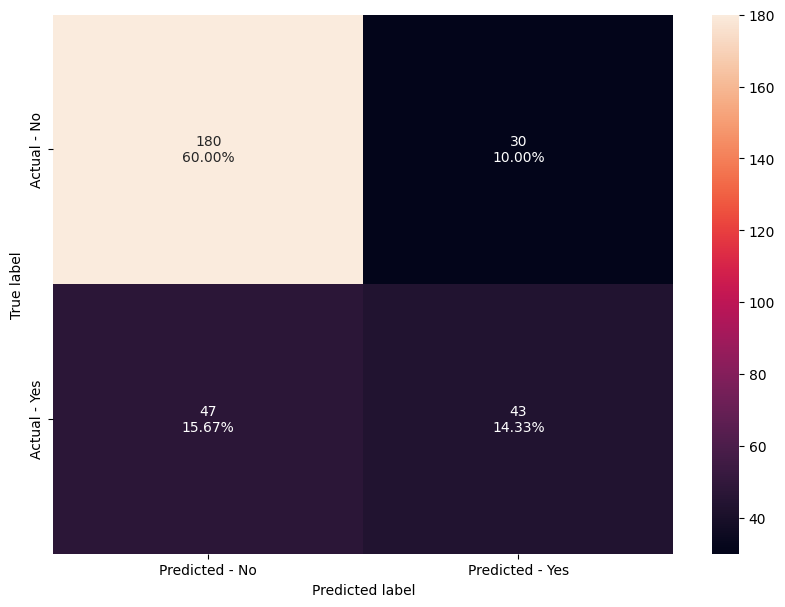

In [19]:
make_confusion_matrix(bagging_estimator,y_test)

### Random Forest Classifier: Default Hyperparameters

In [20]:
rf_estimator=RandomForestClassifier(random_state=1)
rf_estimator.fit(X_train,y_train)

RandomForestClassifier(random_state=1)

In [21]:
rf_estimator_score=get_metrics_score(rf_estimator)

Training Data:
Accuracy:  1.0
Recall:  1.0
Precision:  1.0

Testing Data:
Accuracy:  0.7533333333333333
Recall:  0.4222222222222222
Precision:  0.6333333333333333


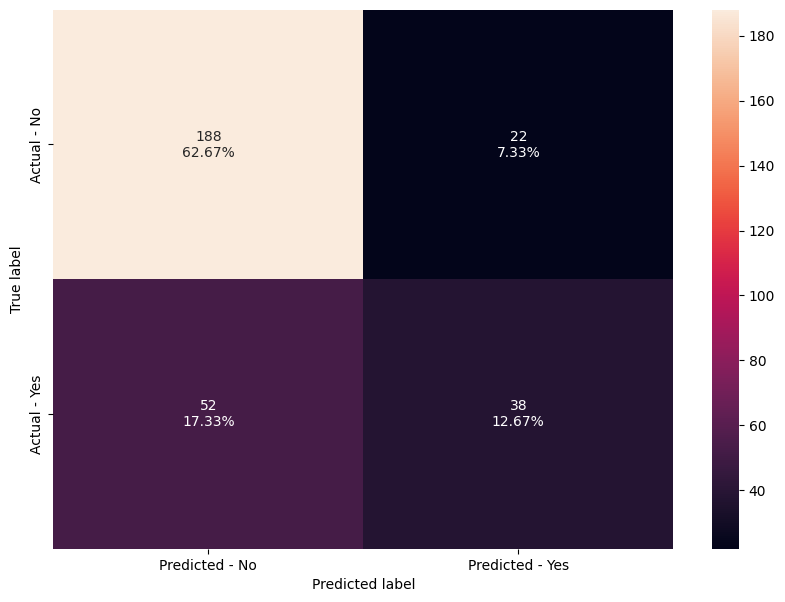

In [22]:
make_confusion_matrix(rf_estimator,y_test)

### Default-Parameter Summary
Both models overfit to the training data.  
Bagging classifier has a better recall score.

## Hyperparameter Tuning

**Some of the important hyperparameters available for bagging classifier are:**

- `base_estimator`: The base estimator to fit on random subsets of the dataset. If None(default), then the base estimator is a decision tree.
- `n_estimators`: The number of trees in the forest, default = 100.
- `max_features`: The number of features to consider when looking for the best split. 
- `bootstrap`: Whether bootstrap samples are used when building trees. If False, the entire dataset is used to build each tree, default=True.
- `bootstrap_features`: If it is true, then features are drawn with replacement. Default value is False.
- `max_samples`: If bootstrap is True, then the number of samples to draw from X to train each base estimator. If None (default), then draw N samples, where N is the number of observations in the train data.
- `oob_score`: Whether to use out-of-bag samples to estimate the generalization accuracy, default=False.

### Baggin Classifier: Grid of Hyperparameters

In [23]:
bagging_estimator_tuned = BaggingClassifier(random_state=1)

# Grid of parameters to choose from
## add from article
parameters = {'max_samples': [0.7,0.8,0.9,1], 
              'max_features': [0.7,0.8,0.9,1],
              'n_estimators' : [10,20,30,40,50],
             }

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.recall_score)

In [24]:
# Run the grid search
grid_obj = GridSearchCV(bagging_estimator_tuned, parameters, scoring=acc_scorer,cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

In [25]:
# Set the clf to the best combination of parameters
bagging_estimator_tuned = grid_obj.best_estimator_

In [26]:
# Fit the best algorithm to the data.
bagging_estimator_tuned.fit(X_train, y_train)

BaggingClassifier(max_features=0.9, max_samples=0.8, n_estimators=40,
                  random_state=1)

In [27]:
#Using above defined function to get accuracy, recall and precision on train and test set
bagging_estimator_tuned_score=get_metrics_score(bagging_estimator_tuned)

Training Data:
Accuracy:  0.9885714285714285
Recall:  0.9619047619047619
Precision:  1.0

Testing Data:
Accuracy:  0.7533333333333333
Recall:  0.45555555555555555
Precision:  0.6212121212121212


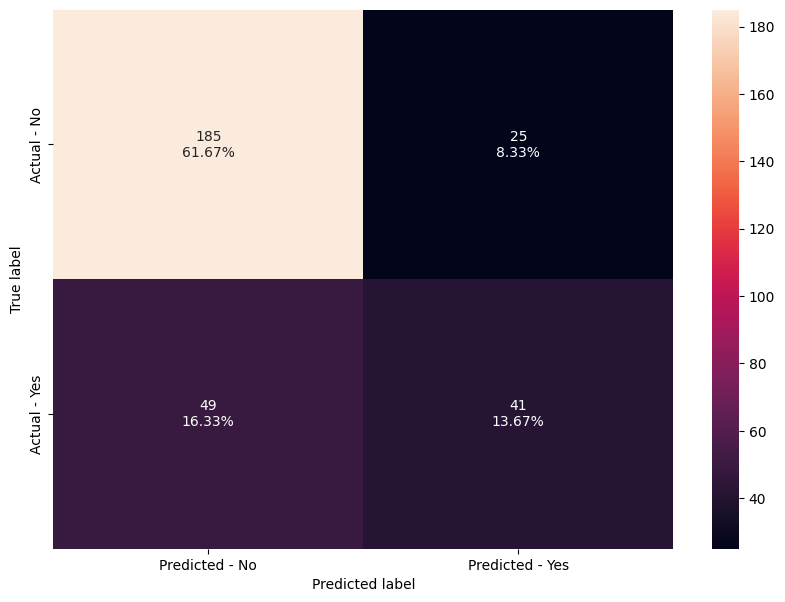

In [28]:
make_confusion_matrix(bagging_estimator_tuned,y_test)

#### Summary
- Training accuracy and recall have increased slightly. Test recall, though, has decreased
- The model is overfitting to the training data.
- The model is better at identifying non-defaulters as compared to defaulters (_see confusion matrix_)

### Bagging Classifier with Logistic regression As The Base Estimator 
By default, the base estimator is a decision tree. Here, using a Logistic Regression.

In [29]:
bagging_lr=BaggingClassifier(base_estimator=LogisticRegression(solver='liblinear',random_state=1,max_iter=1000),random_state=1)
bagging_lr.fit(X_train,y_train)

/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


BaggingClassifier(base_estimator=LogisticRegression(max_iter=1000,
                                                    random_state=1,
                                                    solver='liblinear'),
                  random_state=1)

In [30]:
bagging_lr_score=get_metrics_score(bagging_lr)

Training Data:
Accuracy:  0.7414285714285714
Recall:  0.3380952380952381
Precision:  0.6283185840707964

Testing Data:
Accuracy:  0.7166666666666667
Recall:  0.35555555555555557
Precision:  0.5423728813559322


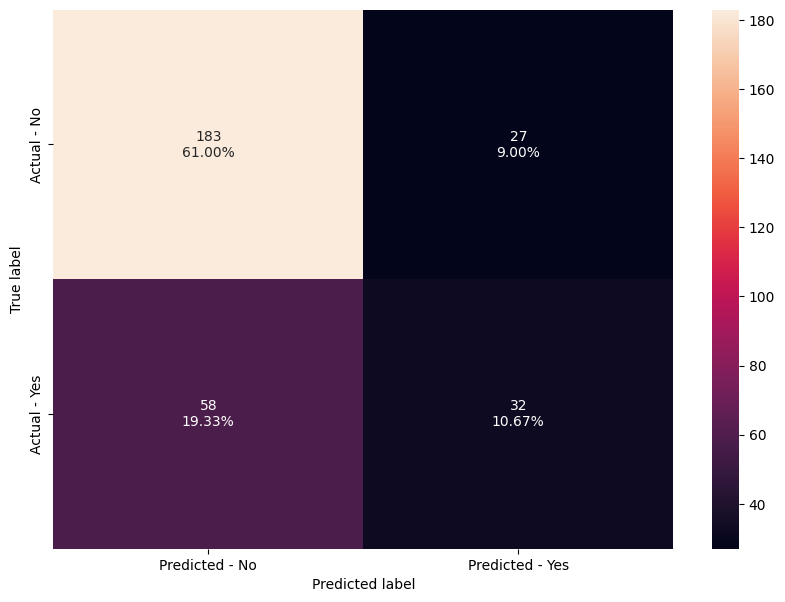

In [31]:
make_confusion_matrix(bagging_lr,y_test)

#### Summary
- This option does NOT overfit to the training data.

### Random Forest Classifier: With Varying Hyperparameters

In [32]:
# build a classifier instance
rf_estimator_tuned = RandomForestClassifier(random_state=1)

In [33]:
# Grid of parameters to choose from
parameters = {
    "n_estimators": [150,200,250],
    "min_samples_leaf": np.arange(5, 10),
    "max_features": np.arange(0.2, 0.7, 0.1),
    "max_samples": np.arange(0.3, 0.7, 0.1),
}

In [34]:
# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.recall_score)

In [35]:
# Run the grid search
grid_obj = GridSearchCV(rf_estimator_tuned, parameters, scoring=acc_scorer,cv=5, n_jobs=4)

In [36]:
# fit training data to the gridSearchCV
grid_obj = grid_obj.fit(X_train, y_train)

In [37]:
# 
# get the best-estimated grid from the combinations of parameters
# 
rf_estimator_tuned = grid_obj.best_estimator_

# 
# fit the training data to the best-estimator
# 
rf_estimator_tuned.fit(X_train, y_train)

RandomForestClassifier(max_features=0.6000000000000001,
                       max_samples=0.6000000000000001, min_samples_leaf=5,
                       n_estimators=150, random_state=1)

In [38]:
#Using above defined function to get accuracy, recall and precision on train and test set
rf_estimator_tuned_score=get_metrics_score(rf_estimator_tuned)

Training Data:
Accuracy:  0.8657142857142858
Recall:  0.6285714285714286
Precision:  0.8918918918918919

Testing Data:
Accuracy:  0.76
Recall:  0.4222222222222222
Precision:  0.6551724137931034


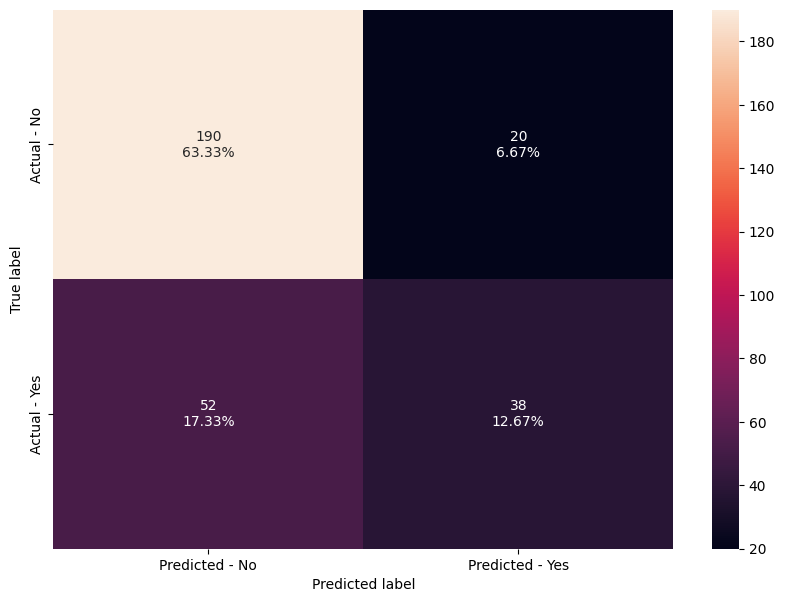

In [39]:
make_confusion_matrix(rf_estimator_tuned,y_test)

#### Summary
- The best estimator here performs better than the default random forest
- This is overfitting to the testing data, but not as much as the tuned bagging classifier
- The test recall is still very low: the model is not that good at identifying defaulters

### Random Forest Classifier: with Classification Weights
The `class_weight` hyperparameter specifies the weights associated with classes. Here, the classification weights will reflect the percentages of each class in the data: 30% and 70%.

In [40]:
# Choose the type of classifier. 
rf_estimator_weighted = RandomForestClassifier(random_state=1)

In [51]:
# Grid of parameters to choose from
## add from article
parameters = {
    "class_weight": [{0: 0.7, 1: 0.3}],
    "n_estimators": [100,150,200,250],
    "min_samples_leaf": np.arange(5, 10),
    "max_features": np.arange(0.2, 0.7, 0.1),
    "max_samples": np.arange(0.3, 0.7, 0.1),
}

In [52]:
# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.recall_score)

In [53]:
# Run the grid search
start_time = time.perf_counter()
grid_obj = GridSearchCV(rf_estimator_weighted, parameters, scoring=acc_scorer,cv=5, n_jobs=4)
end_time = time.perf_counter()
execution_time = end_time - start_time
print(f'execution_time: {execution_time}')

execution_time: 0.0028936250000697328


In [54]:
start_time = time.perf_counter()
grid_obj = grid_obj.fit(X_train, y_train)
end_time = time.perf_counter()
execution_time = end_time - start_time
print(f'execution_time: {execution_time}')

execution_time: 253.30747662500016


In [45]:
# Set the clf to the best combination of parameters
rf_estimator_weighted = grid_obj.best_estimator_

# Fit the best algorithm to the data.
rf_estimator_weighted.fit(X_train, y_train)

RandomForestClassifier(class_weight={0: 0.3, 1: 0.7}, max_features=0.2,
                       max_samples=0.5, min_samples_leaf=7, random_state=1)

In [46]:
#Using above defined function to get accuracy, recall and precision on train and test set
rf_estimator_weighted_score=get_metrics_score(rf_estimator_weighted)

Training Data:
Accuracy:  0.8157142857142857
Recall:  0.7904761904761904
Precision:  0.6613545816733067

Testing Data:
Accuracy:  0.7466666666666667
Recall:  0.6666666666666666
Precision:  0.5660377358490566


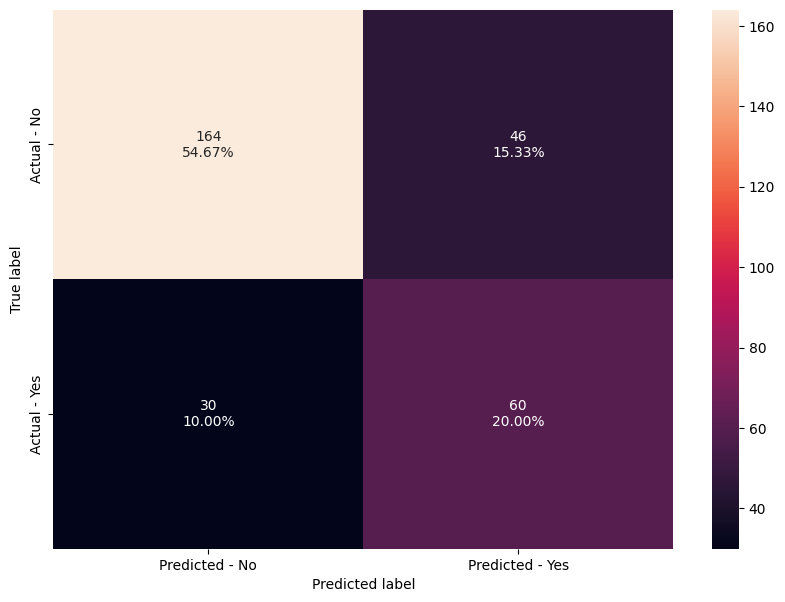

In [47]:
make_confusion_matrix(rf_estimator_weighted,y_test)

#### Summary
This is the best model so far:
- Accuracy has decreased a bit 
- overfitting has decreased
- The train and test recall scores are both higher than the previous models

## Reviewing Feature Importance
Even though the models are complex, the `GridSearchCV` instance has a `feature_importances_` property which can be used to learn about how much "importance" the model considers each feature in the dataset.

In [63]:
importances = rf_estimator_weighted.feature_importances_
indices = np.argsort(importances)
feature_names = list(X.columns)
print(f'importances: {importances}')
print(f'indices: {indices}')
print(f'feature_names: {feature_names}')

importances: [1.87879908e-01 1.25141500e-01 6.64481596e-02 1.32165433e-01
 4.33002781e-02 6.72458197e-02 4.79716985e-02 3.23550357e-02
 1.04293318e-01 1.29471179e-02 6.61575487e-03 2.44883436e-02
 4.18073910e-03 1.67028606e-02 0.00000000e+00 8.14925850e-04
 2.26605724e-02 9.64268142e-05 4.12734380e-03 1.41247705e-02
 1.28766824e-02 1.29341301e-02 2.30123791e-02 2.21997338e-03
 7.43247560e-03 1.73833839e-02 0.00000000e+00 1.05809697e-02]
indices: [14 26 17 15 23 18 12 10 24 27 20 21  9 19 13 25 16 22 11  7  4  6  2  5
  8  1  3  0]
feature_names: ['checking_balance', 'months_loan_duration', 'credit_history', 'amount', 'savings_balance', 'employment_duration', 'percent_of_income', 'years_at_residence', 'age', 'existing_loans_count', 'dependents', 'phone', 'purpose_business', 'purpose_car', 'purpose_car0', 'purpose_education', 'purpose_furniture/appliances', 'purpose_renovations', 'housing_other', 'housing_own', 'housing_rent', 'other_credit_bank', 'other_credit_none', 'other_credit_store

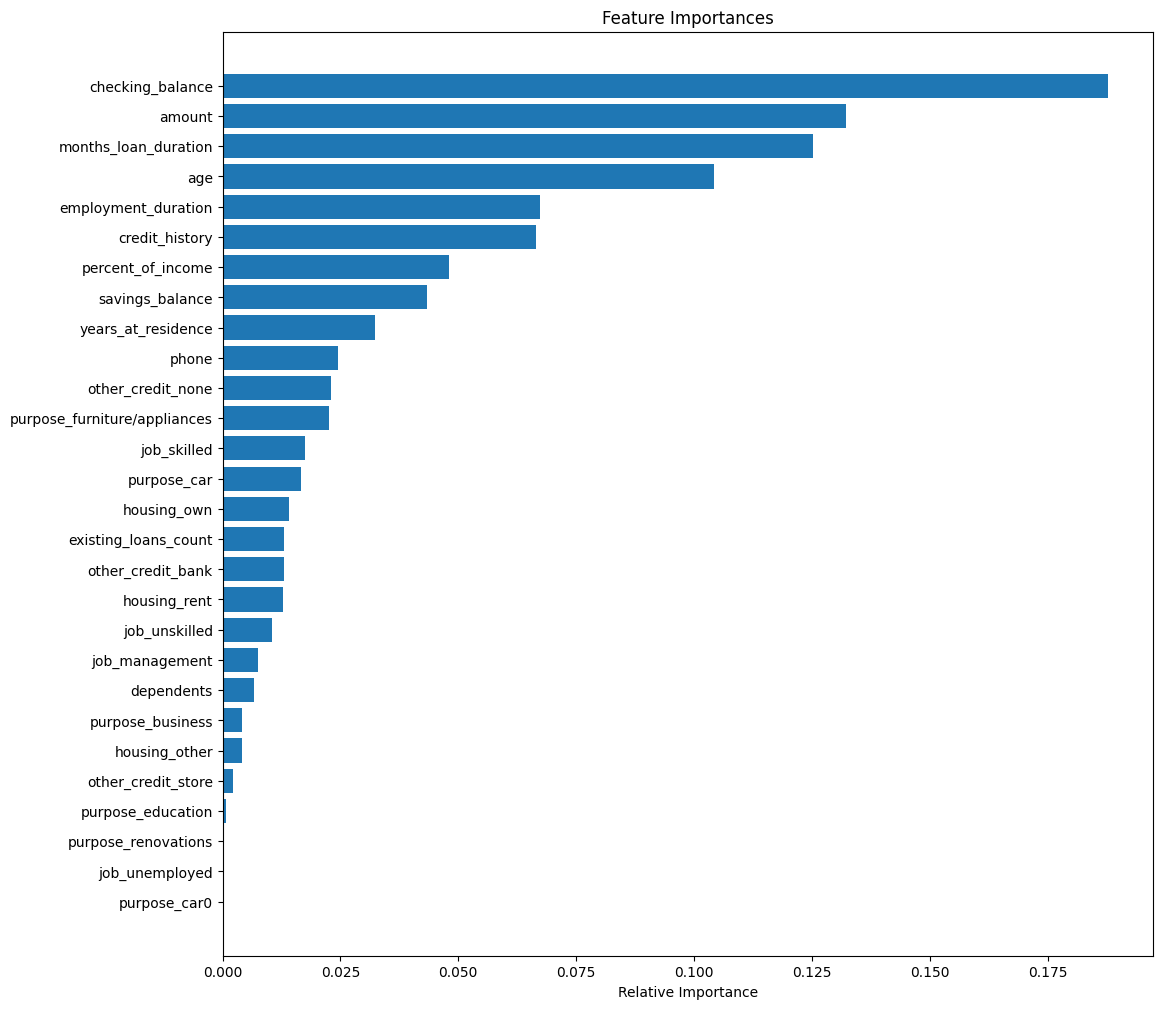

In [64]:
plt.figure(figsize=(12,12))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

## Comparing All Of The Models

In [65]:
allmodels = [bagging_estimator,bagging_estimator_tuned,bagging_lr,rf_estimator,rf_estimator_tuned,
          rf_estimator_weighted]

# defining empty lists to add train and test results
acc_train = []
acc_test = []
recall_train = []
recall_test = []
precision_train = []
precision_test = []

# looping through all the models to get the accuracy, precall and precision scores
for model in allmodels:
    j = get_metrics_score(model,False)
    acc_train.append(np.round(j[0],2))
    acc_test.append(np.round(j[1],2))
    recall_train.append(np.round(j[2],2))
    recall_test.append(np.round(j[3],2))
    precision_train.append(np.round(j[4],2))
    precision_test.append(np.round(j[5],2))

In [68]:
comparison_frame = pd.DataFrame({
    'Model':['Bagging (default)',
             'Bagging Tuned',
             'Bagging + base_estimator=LR', 
             'Random Forest (default)',
             'Random Forest Tuned',
             'Random Forest + class_weights'
            ],
    'Train_Accuracy': acc_train,
    'Test_Accuracy': acc_test,
    'Train_Recall':recall_train,
    'Test_Recall':recall_test,
    'Train_Precision':precision_train,
    'Test_Precision':precision_test
}) 
comparison_frame

,Model,Train_Accuracy,Test_Accuracy,Train_Recall,Test_Recall,Train_Precision,Test_Precision
0,Bagging (default),0.98,0.74,0.94,0.48,0.99,0.59
1,Bagging Tuned,0.99,0.75,0.96,0.46,1.00,0.62
2,Bagging + base_estimator=LR,0.74,0.72,0.34,0.36,0.63,0.54
3,Random Forest (default),1.00,0.75,1.00,0.42,1.00,0.63
4,Random Forest Tuned,0.87,0.76,0.63,0.42,0.89,0.66
5,Random Forest + class_weights,0.82,0.75,0.79,0.67,0.66,0.57


### Model-Building Take-Aways
- Hyperparameter tuning seems complex. **Testing hyperparameter impacts** on a model's performance requires building a model with each hyperparameter variation.
- Untested parameters values and/or combinations leaves unknown model results out of consideration.